In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor, Normalize
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_set = MNIST("./MNIST_dataset", train=True, download=True, transform=Compose([ToTensor(), Normalize((0.1307,), (0.3081,))]))
test_set = MNIST("./MNIST_dataset", train=False, download=True, transform=Compose([ToTensor(), Normalize((0.1307, ),(0.3081, ))]))

In [3]:
train_loader = DataLoader(dataset=train_set, batch_size=16, shuffle=True) 
test_loader = DataLoader(dataset=test_set, batch_size=16, shuffle=False)

In [4]:
data_visual, target_visual = next(iter(train_loader))
print(f"The values of data visualized: {data_visual}, and \n the values of target visualized: {target_visual}")
print(f"The shape of data: {data_visual.shape} and the shape of target: {target_visual.shape}")

The values of data visualized: tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.42

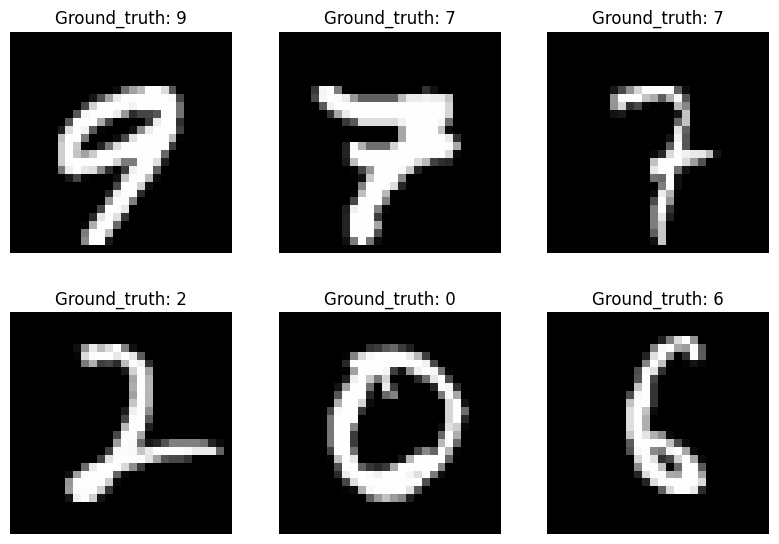

In [5]:
fig = plt.figure(figsize=(8, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.title("Ground_truth: {}".format(target_visual[i]))
    plt.tight_layout()
    plt.imshow(data_visual[i][0], cmap='gray')
    plt.axis("off")
    
plt.show(fig)


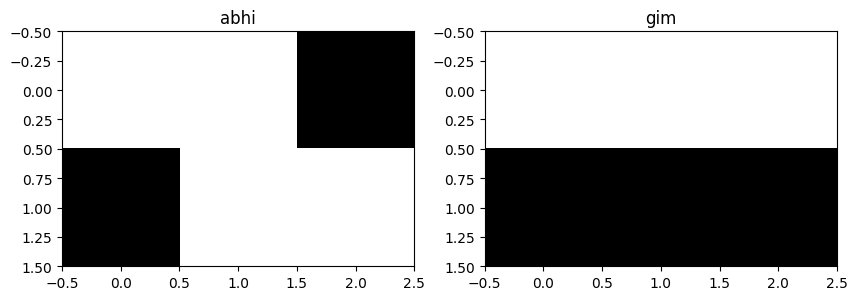

In [6]:
name = ["abhi", "gim", "gemma"]

fig = plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.title("{0}".format(name[0]))
plt.imshow(np.array([[0, 0, 1],
                     [1, 0, 0]]), cmap="binary")
plt.subplot(1, 2, 2)
plt.title("{0}".format(name[1]))
plt.imshow(np.array([[0, 0, 0],
                     [1, 1, 1]]), cmap="binary")

In [7]:
class Classifer(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=in_channel, out_channels=8, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=8, out_channels=32, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(in_features=32*4*4, out_features=64),
            nn.Tanh(),
            nn.Dropout(),
            
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Dropout(),
            
            nn.Linear(32, out_channel)
        )
        
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.shape[0], -1) # similar to x.view(x.size(0), -1) or nn.Flatten() basically used for keeping B from B, C, H, W
        x = self.classifier(x)
        return F.softmax(x)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [9]:
model = Classifer(in_channel=1, out_channel=10).to(device)

In [9]:
data_visual.view(-1, 28).shape

torch.Size([448, 28])

In [10]:
x = torch.randn(16, 32, 4, 4)
x.shape

torch.Size([16, 32, 4, 4])

In [11]:
x.view(x.shape[0], -1).shape

torch.Size([16, 512])

In [10]:
epochs = 50
criterion = nn.CrossEntropyLoss()
alpha = 1e-4

In [11]:
optimizer = optim.Adam(params=model.parameters(), lr=alpha)

In [ ]:
for epoch in range(epochs):
    total_loss = 0
    for idx, data in enumerate(train_loader):
        X, y = data
        X = X.to(device)
        y = y.to(device)
        
        # Forward pass
        y_pred = model(X)        
        
        loss = criterion(y_pred, y)
        total_loss += loss
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # update
        
        optimizer.step()
        
    print(f"Loss: {total_loss/len(train_loader)}, for epoch {epoch+1}/{epochs} ")
        
        

C:\Users\User\AppData\Local\Temp\ipykernel_18552\2696953624.py:30: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Loss: 1.884448766708374, for epoch 1/50 
Loss: 1.5996427536010742, for epoch 2/50 
Loss: 1.5430067777633667, for epoch 3/50 
Loss: 1.5230623483657837, for epoch 4/50 
Loss: 1.5126152038574219, for epoch 5/50 
Loss: 1.5066282749176025, for epoch 6/50 
Loss: 1.5027837753295898, for epoch 7/50 
Loss: 1.499470591545105, for epoch 8/50 
Loss: 1.4974132776260376, for epoch 9/50 
Loss: 1.4945439100265503, for epoch 10/50 
Loss: 1.4928433895111084, for epoch 11/50 
Loss: 1.4905859231948853, for epoch 12/50 
Loss: 1.489393949508667, for epoch 13/50 
Loss: 1.4883743524551392, for epoch 14/50 
Loss: 1.4870425462722778, for epoch 15/50 


In [ ]:
model.eval()
test_loss, correct = 0, 0
with torch.no_grad():
    for idx, data in enumerate(test_loader):
        X, y = data
        X = X.to(device)
        y = y.to(device)
        
        y_pred_val = model(X)
        loss_pred = criterion(y_pred_val, y)
        
        correct = (y_pred_val.argmax(1) == y).count()

In [12]:
X = data_visual.cuda()
y_pred = model(X)
y_pred.shape

C:\Users\User\AppData\Local\Temp\ipykernel_18552\2696953624.py:30: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


torch.Size([16, 10])

In [13]:
target_visual.shape

torch.Size([16])

In [17]:
y_pred.argmax(1)==target_visual.cuda()

tensor([False, False, False, False, False, False, False, False, False, False,
         True, False,  True, False, False, False], device='cuda:0')